# Sine wave prediction using Physics Informed Long Short-Term Memory networks (PI-LSTM)

This code implements the PINT LSTM ([Code](https://github.com/KV-Park/PINT/blob/main/PINT%5BTraining%5D.ipynb) | [Paper](https://arxiv.org/pdf/2502.04018)) to predict and forecast on synthetic data (sine waves).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.stats import pearsonr

from helper_functions import create_sequences, forecast_with_model, set_seed, train_models
from models import LSTM, PhysicsInformedLSTM

* input_size = 1 because we have one feature (value per time step).
* hidden_size is the size of the hidden state.

In [2]:
# Key parameters:
SEED_VALUE = 2026

# Preprocessing
# Experiment 1: Simple sine wave
SEQ_LENGTH = 20  # Number of past time steps to look at 
PRED_LENGTH = 15  # Number of time steps to predict

# Experiment 2:
# seq_length = 20/63 * 365  gives relative proportion out of period (63 for working wave, 365 for climate wave) that is in seq length
# SEQ_LENGTH = 120  # Number of past time steps to look at 
# PRED_LENGTH = 15 # Number of time steps to predict

# Model set up
input_size=1
output_size = PRED_LENGTH
hidden_size=64
num_layers=1
dropout=0
NUM_EPOCHS=50

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
set_seed(SEED_VALUE)

## Make data

In [21]:
# Experiment 1: Simple
t = np.linspace(0, 100, 1000)
freq = 1/(2*np.pi)
amp = 1
phase = 0
data = amp * np.sin(2*(np.pi)*freq*t + phase)

# Experiment 2: Matching climate data
# amp = 1
# freq = 1/365  # where 365 is the period of the data
# phase = 0
# max_time = 1575
# num_timesteps = max_time  # one data point per day

# t = np.linspace(0, max_time, num_timesteps)
# data = amp*np.sin(2*(np.pi)*freq*t + phase)

In [5]:
train = data[:int(len(data)*0.7)]
train_t = t[:int(len(data)*0.7)]
val = data[int(len(data)*0.7):int(len(data)*0.85)]
val_t = t[int(len(data)*0.7):int(len(data)*0.85)]
test = data[int(len(data)*0.85):]
test_t = t[int(len(data)*0.85):]
preds_t = test_t[SEQ_LENGTH:]  # doesn't predict for the first SEQ_LENGTH values of test set, because this is the first sequence used

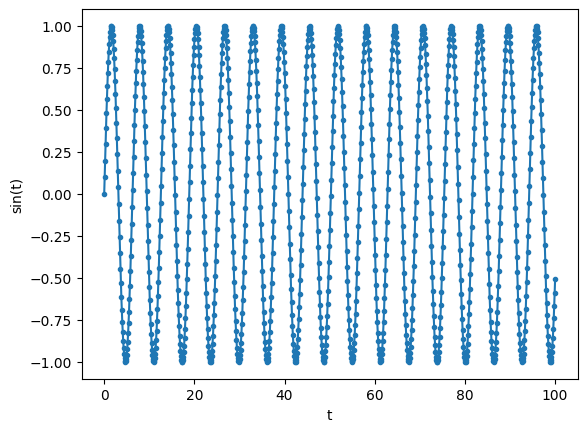

In [6]:
plt.plot(t, data, marker='.')
plt.xlabel("t")
plt.ylabel("sin(t)")
plt.show()

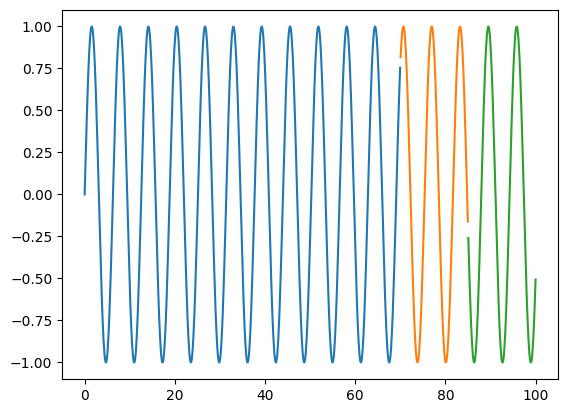

In [7]:
plt.plot(train_t, train, label="Training data")
plt.plot(val_t, val, label="Validation data")
plt.plot(test_t, test, label="Test data")
plt.show()

In [8]:
# Create sequences
X_train, y_train = create_sequences(train, SEQ_LENGTH, PRED_LENGTH)
X_val, y_val = create_sequences(val, SEQ_LENGTH, PRED_LENGTH)
X_test, y_test = create_sequences(test, SEQ_LENGTH, PRED_LENGTH)

# Convert arrays to PyTorch tensors
X_train = torch.Tensor(X_train).unsqueeze(-1) # Shape: (batch, seq, input_size)
y_train = torch.Tensor(y_train)
X_val = torch.Tensor(X_val).unsqueeze(-1) # Shape: (batch, seq, input_size)
y_val = torch.Tensor(y_val)
X_test = torch.Tensor(X_test).unsqueeze(-1)
y_test = torch.Tensor(y_test)

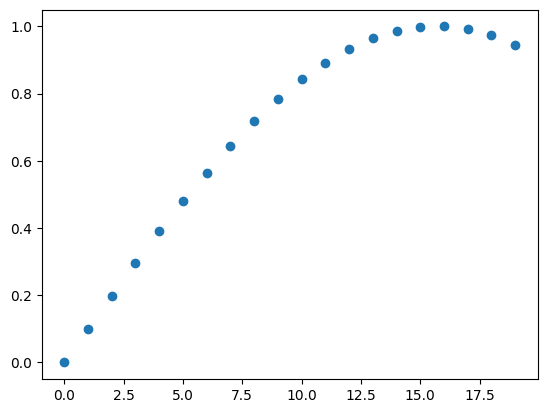

In [9]:
plt.scatter(np.arange(SEQ_LENGTH), X_train[0])

In [10]:
len_data = len(X_train) + len(X_val) + len(X_test)
print(f"Train:val:test ratio: {len(X_train)}:\
{len(X_val)}:{len(X_test)}")
print(f"Train:val:test ratio: \
{len(X_train)/len_data*100:.2f}%:\
{len(X_val)/len_data*100:.2f}%:\
{len(X_test)/len_data*100:.2f}%")

Train:val:test ratio: 666:116:116
Train:val:test ratio: 74.16%:12.92%:12.92%


## Define and train models

In [22]:
# Initialise models
omega = 2 * np.pi * 1/freq
models = {
    "LSTM": LSTM(input_size, hidden_size, num_layers, output_size),
    "PI-LSTM": PhysicsInformedLSTM(input_size, hidden_size, num_layers, output_size, omega_init=omega)
}

=== Starting training ===
Training Standard Model: LSTM
Epoch [10/50], Loss: 0.2179
Epoch [20/50], Loss: 0.0645
Epoch [30/50], Loss: 0.0145
Epoch [40/50], Loss: 0.0032
Epoch [50/50], Loss: 0.0018


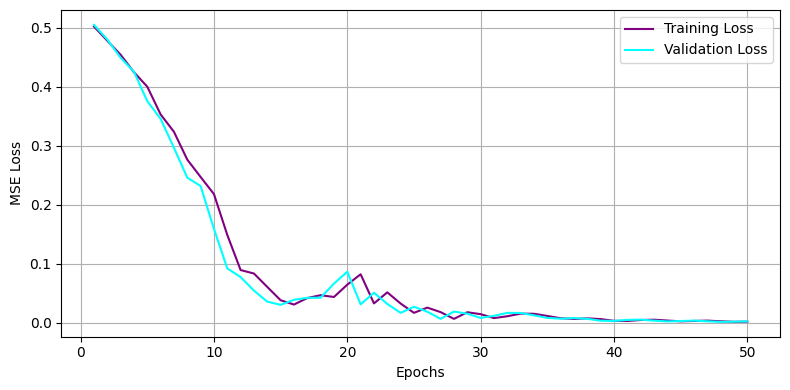

Training Physics-Informed Model: PI-LSTM
Epoch [10/50], Loss: 0.2065
Epoch [20/50], Loss: 0.0382
Epoch [30/50], Loss: 0.0076
Epoch [40/50], Loss: 0.0037
Epoch [50/50], Loss: 0.0010


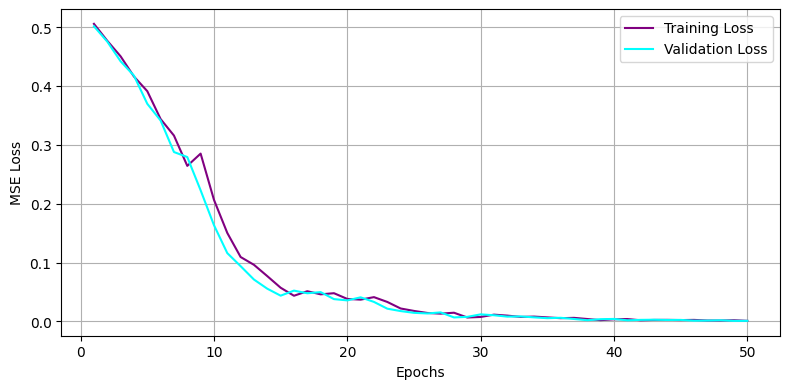

In [23]:
print("=== Starting training ===")
train_models(models, X_train, y_train, X_val, y_val, num_epochs=NUM_EPOCHS)

## Evaluate
Check if predicted sequences align with true values


In [24]:
colours = {
    "Ground truth": "#1589e8",
    "LSTM": "#dc267f",
    "PI-LSTM": "#ffb000",
    "Starting data": "#631ff3"
}
    # "#631ff3", "#fe5100" # - IBM colourblind palette

In [25]:
y_preds = {}
for name, model in models.items():
    model.eval()
    with torch.no_grad():
        preds = model(X_test).squeeze().numpy()
        y_preds[name] = preds # Predict on test set

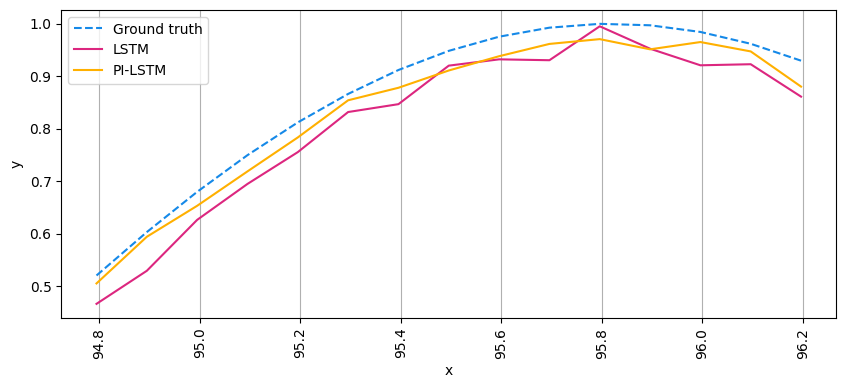

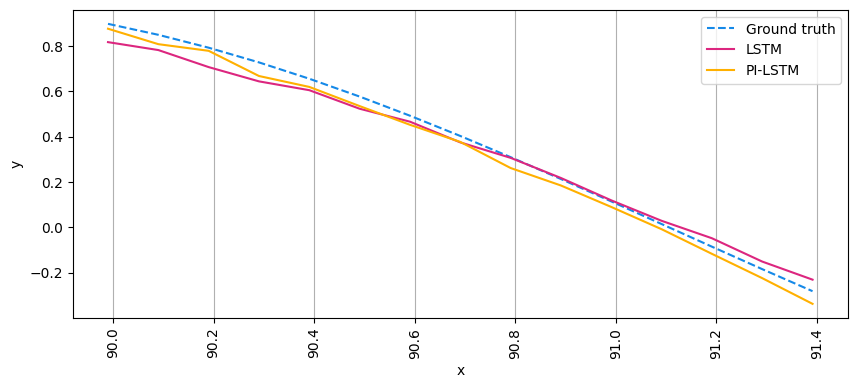

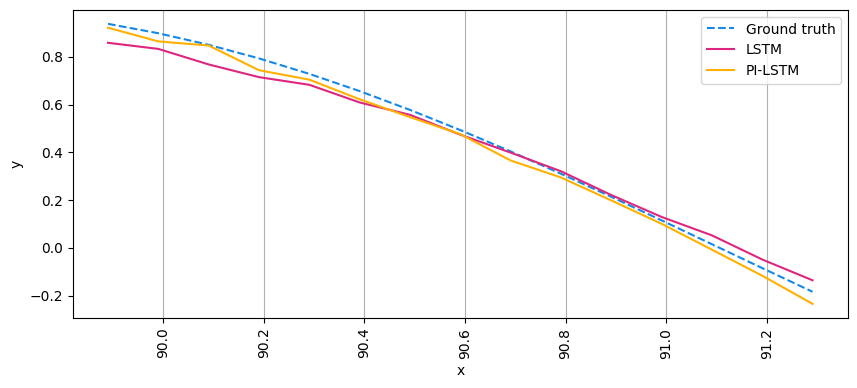

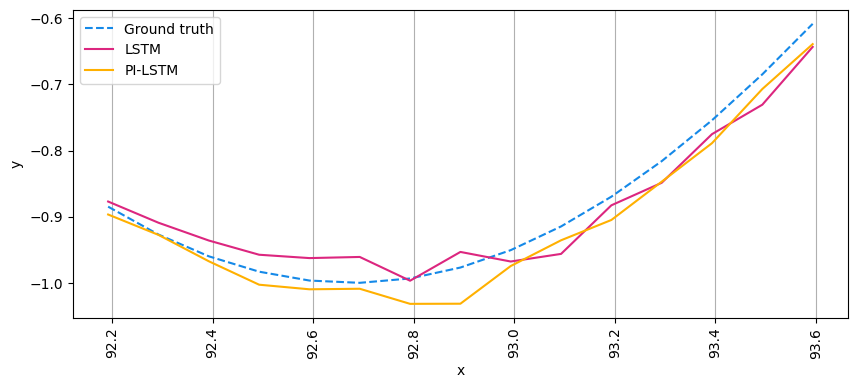

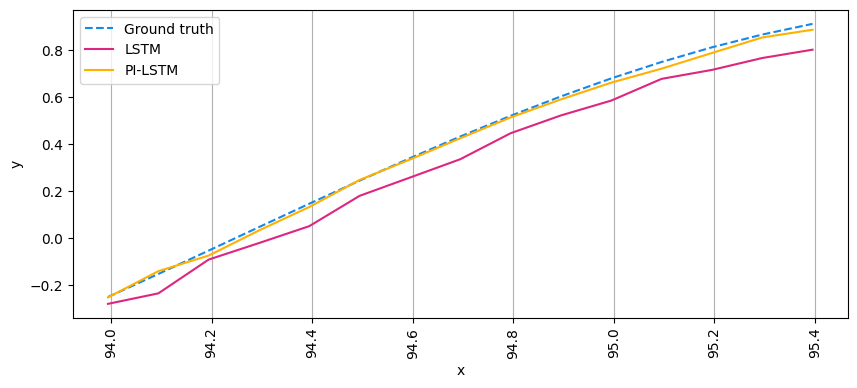

In [26]:
# Plot 5 random examples from test set!
for i in np.random.choice(range(len(y_test)-SEQ_LENGTH-1), 5):
    # Plot actual vs predicted 
    plt.figure(figsize=(10, 4))
    times = preds_t[i:i+PRED_LENGTH]
    plt.plot(times, y_test[i], '--', label='Ground truth', c=colours['Ground truth'])
    for name in models.keys():
        plt.plot(times, y_preds[name][i], label=name, c=colours[name])
    ax = plt.gca()
    ax.grid(visible=True, axis="x")
    plt.xticks(rotation=90)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.show()

In [38]:
y_preds["LSTM"].squeeze().shape

(116, 15)

In [51]:
y_preds['LSTM'][0].shape

(15,)

In [1]:
for name in models.keys():
    # Calculate RMSE
    rmse = [np.sqrt(np.mean((y_preds[name][i] - np.array(y_test[i])) ** 2)) for i in range(len(y_preds[name]))]
    
    # Calculate Pearson correlation
    correlation, _ = pearsonr(y_preds[name].squeeze(), np.array(y_test))

    print(f"Metrics for model - {name}:")
    print(f"RMSE:\t\t{np.mean(rmse)} +/- {np.std(rmse)}")
    print(f"P-CORR:\t\t{np.mean(correlation)} +/- {np.std(correlation)}")

NameError: name 'models' is not defined

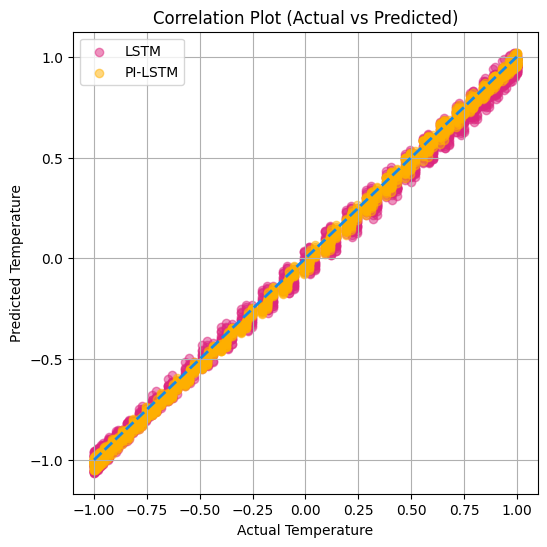

In [27]:
plt.figure(figsize=(6, 6))
for name in models.keys():
    plt.scatter(y_test.reshape(-1,1), y_preds[name].reshape(-1,1), alpha=0.5, label=name, c=colours[name])
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         '--', lw=2, c=colours['Ground truth'])
plt.title('Correlation Plot (Actual vs Predicted)')
plt.xlabel('Actual Temperature')
plt.ylabel('Predicted Temperature')
plt.grid(True)
plt.legend()
plt.show()

## Autoregressive Forecasting

In [28]:
y_forecast = {}
start_data = X_test[0:1]  # Starting data: first sequence of X_test
desired_length = len(test)-SEQ_LENGTH
for name, model in models.items():
    print(f"Forcasting for model: {name}")
    y_forecast[name] = forecast_with_model(model, start_data, desired_length, PRED_LENGTH)

Forcasting for model: LSTM
Forcasting for model: PI-LSTM


In [29]:
for name in models.keys():
    # Calculate RMSE
    rmse = np.sqrt(np.mean((y_forecast[name].squeeze() - test[SEQ_LENGTH:]) ** 2))

    # Calculate Pearson correlation
    correlation, _ = pearsonr(y_forecast[name].squeeze(), test[SEQ_LENGTH:])

    print(f"Metrics for model - {name}:")
    print(f"RMSE:\t\t{rmse}")
    print(f"P-CORR:\t\t{correlation}")

Metrics for model - LSTM:
RMSE:		0.07079324652836073
P-CORR:		0.9974725367347744
Metrics for model - PI-LSTM:
RMSE:		0.05673169523069426
P-CORR:		0.9975657902897974


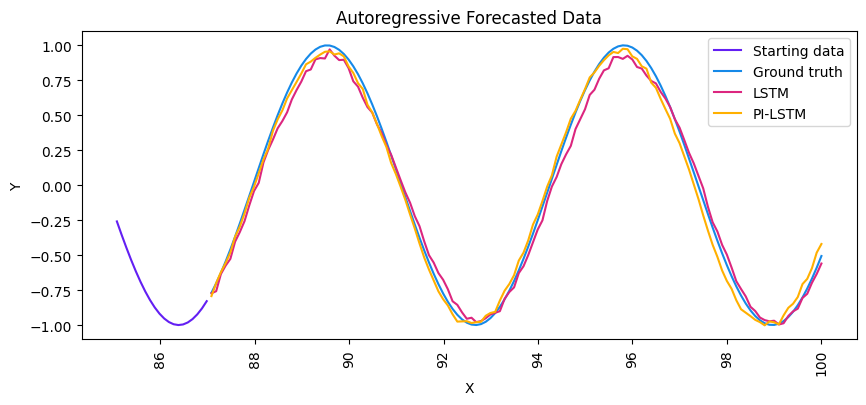

In [30]:
# Plot actual vs predicted
plt.figure(figsize=(10, 4))

# Starting data: first sequence of X_test
plt.plot(test_t[:SEQ_LENGTH], start_data.squeeze(), label='Starting data', c=colours['Starting data'])

# Ground truth: test data across region predicted for
plt.plot(preds_t, test[SEQ_LENGTH:], label='Ground truth', c=colours['Ground truth'])

# Predictions
for name in models.keys():
    plt.plot(preds_t, y_forecast[name], label=name, c=colours[name])
plt.title("Autoregressive Forecasted Data")
ax = plt.gca()
plt.xticks(rotation=90)
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()

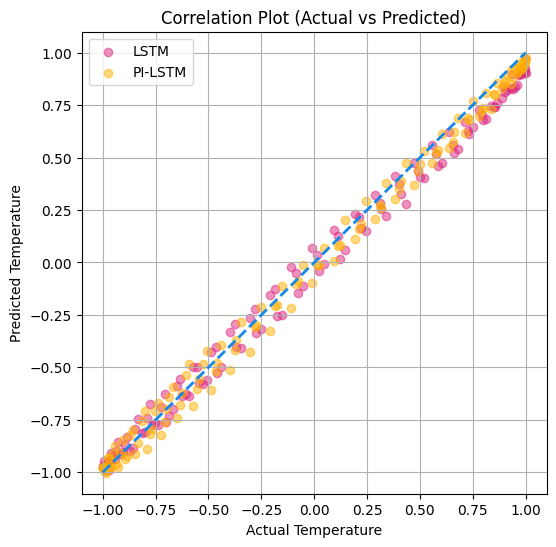

In [31]:
plt.figure(figsize=(6, 6))
for name in models.keys():
    plt.scatter(test[SEQ_LENGTH:], y_forecast[name], alpha=0.5, label=name, c=colours[name])
plt.plot([test[SEQ_LENGTH:].min(), test[SEQ_LENGTH:].max()], 
         [test[SEQ_LENGTH:].min(), test[SEQ_LENGTH:].max()], 
         '--', lw=2, c=colours['Ground truth'])
plt.title('Correlation Plot (Actual vs Predicted)')
plt.xlabel('Actual Temperature')
plt.ylabel('Predicted Temperature')
plt.grid(True)
plt.legend()
plt.show()
